In [2]:
# Importing the libraries
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Allow plots to appear within the notebook
%matplotlib inline

In [3]:
data = pd.read_csv('supermarket_sales.csv')

# Display the first 5 rows
data.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
le = LabelEncoder()
data['Branch'] = le.fit_transform(data['Branch'])
data['City'] = le.fit_transform(data['City'])
data['Customer type'] = le.fit_transform(data['Customer type'])
data['Gender'] = le.fit_transform(data['Gender'])
data['Product line'] = le.fit_transform(data['Product line'])
data['Payment'] = le.fit_transform(data['Payment'])

In [5]:
data.dtypes

Invoice ID                  object
Branch                       int64
City                         int64
Customer type                int64
Gender                       int64
Product line                 int64
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                      int64
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [7]:
data.dtypes

Invoice ID                  object
Branch                       int64
City                         int64
Customer type                int64
Gender                       int64
Product line                 int64
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                      int64
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [8]:
data.drop(['Invoice ID', 'Date', 'Time', 'gross margin percentage', 'Payment'], axis=1, inplace=True)

In [9]:
data.head()

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,cogs,gross income,Rating
0,0,2,0,0,3,74.69,7,26.1415,548.9715,522.83,26.1415,9.1
1,2,1,1,0,0,15.28,5,3.8200,80.2200,76.40,3.8200,9.6
2,0,2,1,1,4,46.33,7,16.2155,340.5255,324.31,16.2155,7.4
3,0,2,0,1,3,58.22,8,23.2880,489.0480,465.76,23.2880,8.4
4,0,2,1,1,5,86.31,7,30.2085,634.3785,604.17,30.2085,5.3


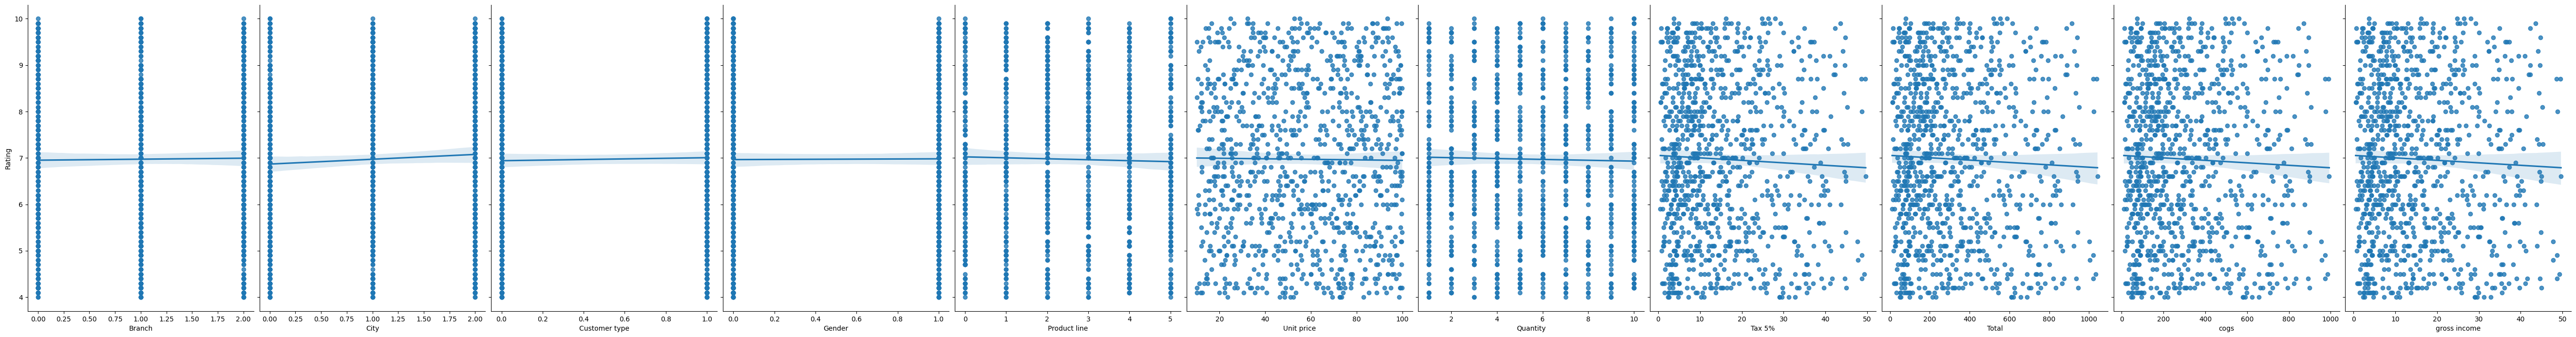

In [10]:
sns.pairplot(data, x_vars=['Branch','City','Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'cogs', 'gross income'], y_vars='Rating', height=7, aspect=0.7, kind='reg')

<Axes: >

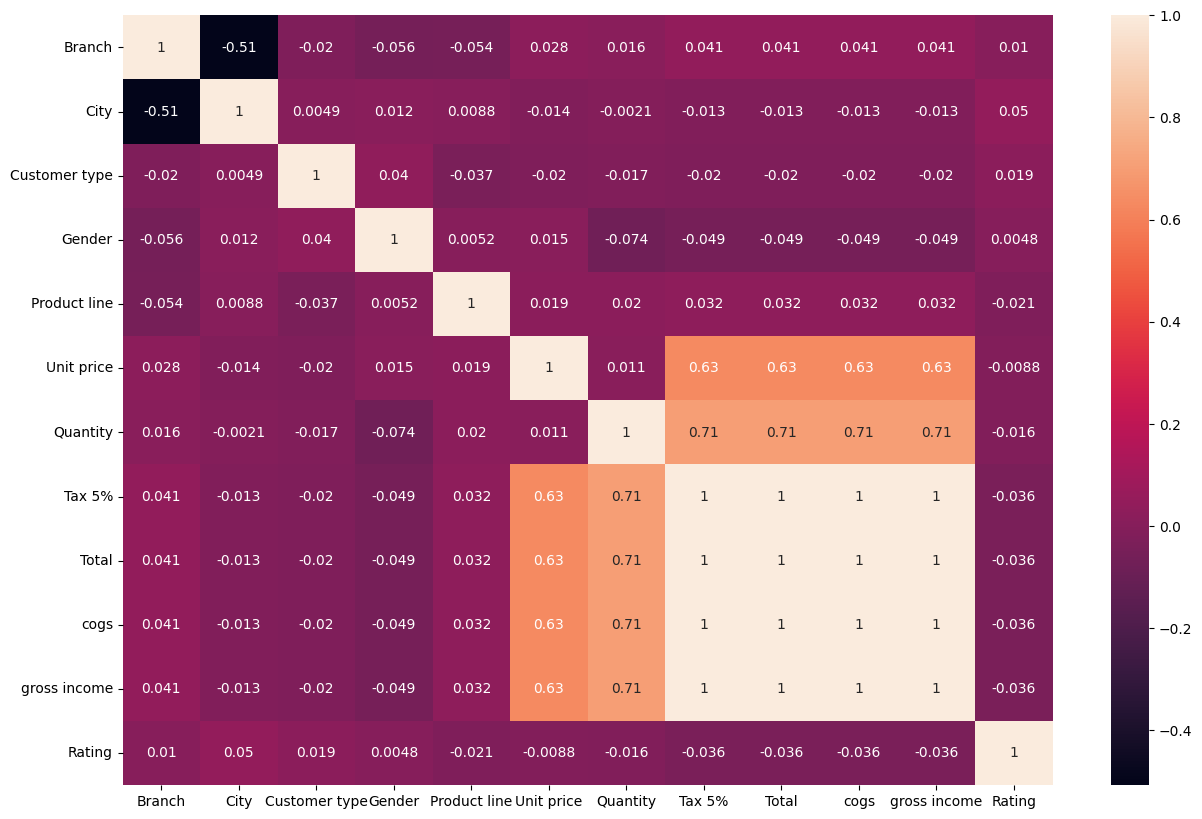

In [11]:
fig, ax = plt.subplots(figsize=(15, 10)) 
sns.heatmap(data.corr(), annot=True, ax=ax)

In [ ]:
data.drop(['Tax 5%', 'Total', 'cogs', 'gross income'], inplace=True, axis=1)

In [13]:
feature_cols = ['Branch', 'City', 'Customer type','Unit price', 'Product line', 'Gender']
X = data[feature_cols]
X.head()

,Branch,City,Customer type,Unit price,Product line,Gender
0,0,2,0,74.69,3,0
1,2,1,1,15.28,0,0
2,0,2,1,46.33,4,1
3,0,2,0,58.22,3,1
4,0,2,1,86.31,5,1


In [14]:
y = data['Rating']
y.head()

0    9.1
1    9.6
2    7.4
3    8.4
4    5.3
Name: Rating, dtype: float64

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [16]:
linreg = LinearRegression()

linreg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:

list(zip(feature_cols, linreg.coef_))

[('Branch', np.float64(0.1594495022086524)),
 ('City', np.float64(0.20786225889040008)),
 ('Customer type', np.float64(0.013523391023705091)),
 ('Unit price', np.float64(-0.0020495485650192935)),
 ('Product line', np.float64(-0.020126224233631567)),
 ('Gender', np.float64(0.01787127301583516))]

In [29]:
print(linreg.intercept_)
print(linreg.coef_)

6.739615109561298
[ 0.1594495   0.20786226  0.01352339 -0.00204955 -0.02012622  0.01787127]


In [30]:
y_pred = linreg.predict(X_test)
print(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print(metrics.mean_absolute_error(y_test, y_pred))
print(metrics.mean_squared_error(y_test, y_pred))

# So we can append them
linreg_rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
linreg_mae = metrics.mean_absolute_error(y_test, y_pred)
linreg_mse = metrics.mean_squared_error(y_test, y_pred)

1.690899216293913
1.448114533974033
2.859140159663369


In [31]:
mae_results = []
mse_results = []
rmse_results = []

mae_results.append(linreg_mae)
mse_results.append(linreg_mse)
rmse_results.append(linreg_rmse)

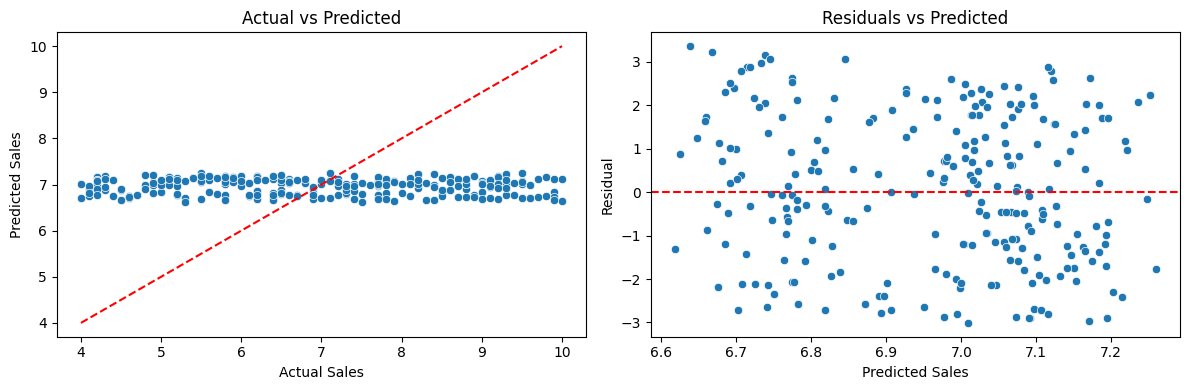

In [32]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')

sns.scatterplot(x=y_pred, y=residuals, ax=axes[1])
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residual')
plt.tight_layout()

In [23]:
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print(metrics.mean_absolute_error(y_test, y_pred))
print(metrics.mean_squared_error(y_test, y_pred))

mae_results.append(metrics.mean_absolute_error(y_test, y_pred))
mse_results.append(metrics.mean_squared_error(y_test, y_pred))
rmse_results.append(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

1.860917193214142
1.5592799999999998
3.4630128


In [24]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=1)

rf_reg.fit(X_train, y_train)

y_pred = rf_reg.predict(X_test)

print(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print(metrics.mean_absolute_error(y_test, y_pred))
print(metrics.mean_squared_error(y_test, y_pred))

mae_results.append(metrics.mean_absolute_error(y_test, y_pred))
mse_results.append(metrics.mean_squared_error(y_test, y_pred))
rmse_results.append(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

1.824288583888764
1.5329570380952382
3.3280288373068716


In [25]:
svr = SVR()

svr.fit(X_train, y_train)

y_pred = svr.predict(X_test)

print(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print(metrics.mean_absolute_error(y_test, y_pred))
print(metrics.mean_squared_error(y_test, y_pred))

mae_results.append(metrics.mean_absolute_error(y_test, y_pred))
mse_results.append(metrics.mean_squared_error(y_test, y_pred))
rmse_results.append(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

1.6949005687327685
1.4549021586732391
2.8726879378906625


In [26]:
xgb_reg = XGBRegressor(n_estimators=100, random_state=1)

xgb_reg.fit(X_train, y_train)

y_pred = xgb_reg.predict(X_test)

print(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print(metrics.mean_absolute_error(y_test, y_pred))
print(metrics.mean_squared_error(y_test, y_pred))

mae_results.append(metrics.mean_absolute_error(y_test, y_pred))
mse_results.append(metrics.mean_squared_error(y_test, y_pred))
rmse_results.append(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

2.002890655728123
1.6348678730010986
4.011570978803031


In [27]:
results = pd.DataFrame(list(zip(mae_results, mse_results, rmse_results)),
                        index=["Linear Regression",'KNN', 'Random Forest', 'SVR', 'XGBoost'],
                        columns=['MAE', 'MSE', 'RMSE'])

results

,MAE,MSE,RMSE
Linear Regression,1.448115,2.859140,1.690899
KNN,1.559280,3.463013,1.860917
Random Forest,1.532957,3.328029,1.824289
SVR,1.454902,2.872688,1.694901
XGBoost,1.634868,4.011571,2.002891
